# Netflix Prize — Recommendation System



---

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Preprocessing](#2-data-loading--preprocessing)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Train-Test Split](#4-train-test-split)
5. [Model 1 — SVD (Matrix Factorization)](#5-model-1--svd-matrix-factorization)
6. [Model 2 — User-Based Collaborative Filtering](#6-model-2--user-based-collaborative-filtering)
7. [Model Comparison](#7-model-comparison)
8. [Top-K Recommendation Generation](#8-top-k-recommendation-generation)
9. [Evaluation (RMSE + MAP@10)](#9-evaluation)
10. [Success & Failure Case Analysis](#10-success--failure-case-analysis)
11. [Conclusion](#11-conclusion)

---
## 1. Environment Setup

In [1]:
# Install required libraries (run once)
# !pip install surprise pandas numpy matplotlib seaborn scikit-learn scipy tqdm

import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cosine

from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_split

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 2. Data Loading & Preprocessing

The Netflix Prize dataset consists of four rating files (`combined_data_1.txt` through `combined_data_4.txt`) and a movie titles file (`movie_titles.csv`).  
Due to the scale of the full dataset (~100M ratings), we sample a **representative subset** of 1,000 randomly chosen movies to keep training feasible while preserving statistical properties.

In [2]:
# ─── CONFIGURE PATHS ──────────────────────────────────────────────────────────
# Update DATA_DIR to wherever you extracted the Kaggle dataset
DATA_DIR = r'C:\Users\tejal\Documents\netflix-prize-data'

RATING_FILES = [
    os.path.join(DATA_DIR, 'combined_data_1.txt'),
    os.path.join(DATA_DIR, 'combined_data_2.txt'),
    os.path.join(DATA_DIR, 'combined_data_3.txt'),
    os.path.join(DATA_DIR, 'combined_data_4.txt'),
]
MOVIE_FILE = os.path.join(DATA_DIR, 'movie_titles.csv')

# Sampling parameters
N_MOVIES_SAMPLE   = 1000   # number of movies to keep
MIN_USER_RATINGS  = 50     # users must have rated ≥50 movies in the sample
MIN_MOVIE_RATINGS = 20     # movies must have ≥20 ratings in the sample

In [3]:
def parse_netflix_ratings(file_paths):
    """Parse raw Netflix combined_data_*.txt files into a DataFrame."""
    records = []
    current_movie = None

    for path in file_paths:
        print(f"Parsing {os.path.basename(path)} ...")
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                if i > 2000000: # Stops after 2 million rows per file
                    break
            for line in f:
                line = line.strip()
                if line.endswith(':'):
                    current_movie = int(line[:-1])
                else:
                    parts = line.split(',')
                    if len(parts) == 3:
                        records.append((current_movie, int(parts[0]),
                                        int(parts[1]), parts[2]))

    df = pd.DataFrame(records, columns=['movie_id', 'user_id', 'rating', 'date'])
    df['date'] = pd.to_datetime(df['date'])
    return df


def load_movie_titles(path):
    """Load movie_titles.csv, handling encoding issues."""
    movies = pd.read_csv(
        path,
        encoding='latin-1',
        header=None,
        names=['movie_id', 'year', 'title'],
        on_bad_lines='skip'
    )
    movies['year'] = pd.to_numeric(movies['year'], errors='coerce')
    return movies


# ─── LOAD ─────────────────────────────────────────────────────────────────────
print("Loading ratings (this may take a few minutes for the full dataset)...")
df_raw = parse_netflix_ratings(RATING_FILES)
movies_df = load_movie_titles(MOVIE_FILE)

print(f"\nRaw ratings shape : {df_raw.shape}")
print(f"Unique users       : {df_raw['user_id'].nunique():,}")
print(f"Unique movies      : {df_raw['movie_id'].nunique():,}")
df_raw.head()

Loading ratings (this may take a few minutes for the full dataset)...
Parsing combined_data_1.txt ...
Parsing combined_data_2.txt ...
Parsing combined_data_3.txt ...
Parsing combined_data_4.txt ...

Raw ratings shape : (92481932, 4)
Unique users       : 480,096
Unique movies      : 16,337


,movie_id,user_id,rating,date
0,NaN,485175,4,2005-07-08
1,NaN,773045,3,2005-07-09
2,NaN,754918,4,2005-07-09
3,NaN,1192062,3,2005-07-10
4,NaN,557504,3,2005-07-11


In [4]:
# ─── SAMPLING ─────────────────────────────────────────────────────────────────
print("Sampling dataset for computational feasibility...")

# Pick N_MOVIES_SAMPLE movies randomly
sampled_movies = np.random.choice(
    df_raw['movie_id'].unique(), size=N_MOVIES_SAMPLE, replace=False
)
df = df_raw[df_raw['movie_id'].isin(sampled_movies)].copy()

# Filter users and movies for density
user_counts  = df['user_id'].value_counts()
movie_counts = df['movie_id'].value_counts()

df = df[
    df['user_id'].isin(user_counts[user_counts >= MIN_USER_RATINGS].index) &
    df['movie_id'].isin(movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index)
]

# Re-map IDs to contiguous integers
user_map  = {u: i for i, u in enumerate(df['user_id'].unique())}
movie_map = {m: i for i, m in enumerate(df['movie_id'].unique())}
df['user_idx']  = df['user_id'].map(user_map)
df['movie_idx'] = df['movie_id'].map(movie_map)

n_users  = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()
n_ratings = len(df)
sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"\nSampled dataset stats")
print(f"  Ratings   : {n_ratings:,}")
print(f"  Users     : {n_users:,}")
print(f"  Movies    : {n_movies:,}")
print(f"  Sparsity  : {sparsity:.4%}")
df.head()

Sampling dataset for computational feasibility...

Sampled dataset stats
  Ratings   : 1,235,765
  Users     : 17,224
  Movies    : 999
  Sparsity  : 92.8181%


,movie_id,user_id,rating,date,user_idx,movie_idx
33029,364.0,537732,3,2004-10-16,0,0
33036,364.0,1189269,5,2004-12-25,1,0
33053,364.0,921783,2,2004-06-08,2,0
33054,364.0,844526,5,2004-04-13,3,0
33057,364.0,167041,3,2004-05-06,4,0


---
## 3. Exploratory Data Analysis

We analyse four dimensions: rating distribution, user activity, content popularity, and temporal patterns.

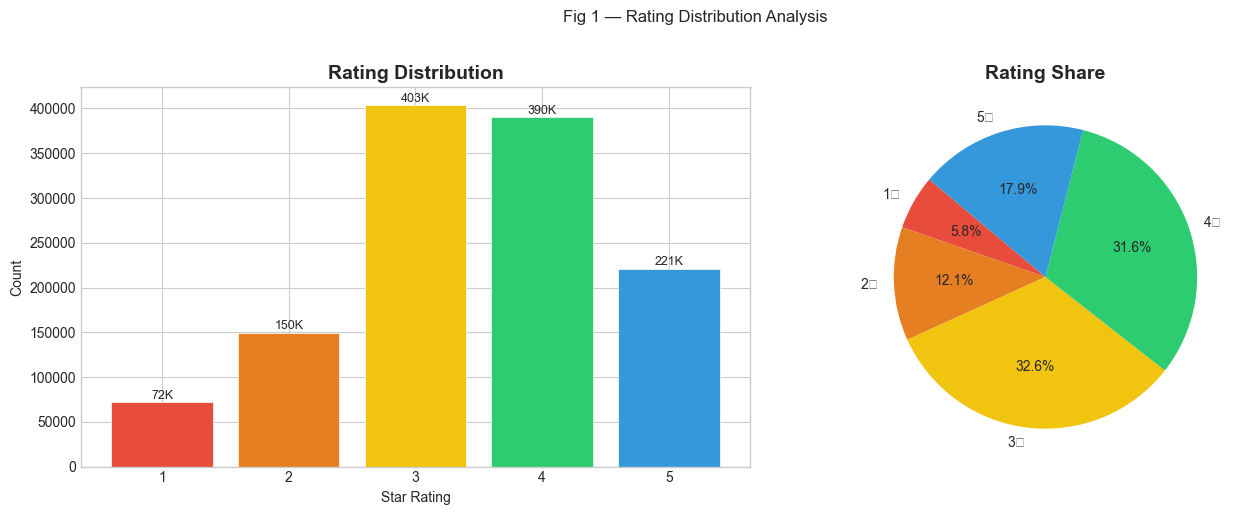


Rating Statistics:
count    1.235765e+06
mean     3.436496e+00
std      1.092481e+00
min      1.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      5.000000e+00

Mean rating  : 3.436
Median rating: 3.0
Mode rating  : 3


In [5]:
# ── 3.1 Rating Distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'],
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
for bar, count in zip(axes[0].patches, rating_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count/1000:.0f}K', ha='center', va='bottom', fontsize=9)

axes[1].pie(rating_counts.values, labels=[f'{r}★' for r in rating_counts.index],
            autopct='%1.1f%%', startangle=140,
            colors=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[1].set_title('Rating Share', fontsize=14, fontweight='bold')

plt.suptitle('Fig 1 — Rating Distribution Analysis', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig1_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRating Statistics:")
print(df['rating'].describe().to_string())
print(f"\nMean rating  : {df['rating'].mean():.3f}")
print(f"Median rating: {df['rating'].median():.1f}")
print(f"Mode rating  : {df['rating'].mode()[0]}")

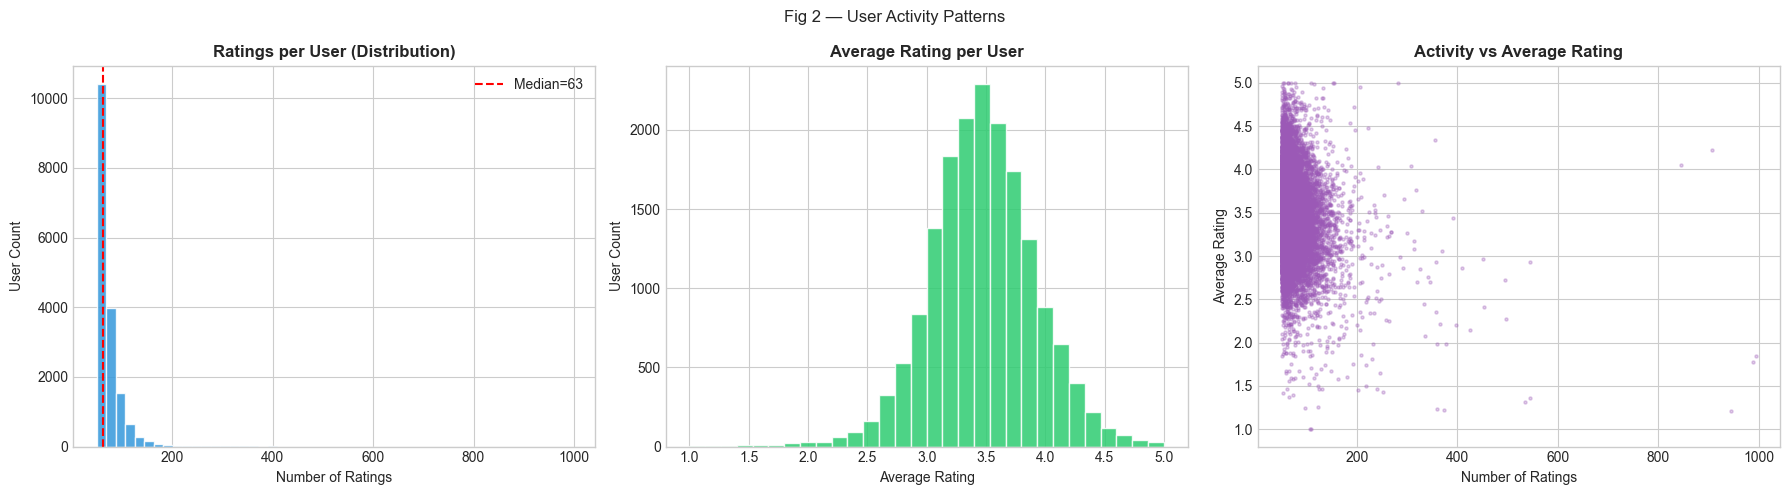


User Activity Summary:
count    17224.000000
mean        71.746691
std         31.331704
min         50.000000
25%         55.000000
50%         63.000000
75%         78.000000
max        995.000000

 Top-5 most active users:
 user_id  n_ratings  avg_rating
  305344        995    1.849246
  387418        988    1.775304
 2439493        944    1.211864
 1664010        907    4.226020
 2118461        845    4.054438


In [6]:
# ── 3.2 User Activity Patterns ────────────────────────────────────────────────
user_activity = df.groupby('user_id').agg(
    n_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    rating_std=('rating', 'std')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(user_activity['n_ratings'], bins=50, color='#3498db',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Ratings per User (Distribution)', fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('User Count')
axes[0].axvline(user_activity['n_ratings'].median(), color='red',
                linestyle='--', label=f"Median={user_activity['n_ratings'].median():.0f}")
axes[0].legend()

axes[1].hist(user_activity['avg_rating'], bins=30, color='#2ecc71',
             edgecolor='white', alpha=0.85)
axes[1].set_title('Average Rating per User', fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('User Count')

axes[2].scatter(user_activity['n_ratings'], user_activity['avg_rating'],
                alpha=0.3, s=5, color='#9b59b6')
axes[2].set_title('Activity vs Average Rating', fontweight='bold')
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Average Rating')

plt.suptitle('Fig 2 — User Activity Patterns', fontsize=12)
plt.tight_layout()
plt.savefig('fig2_user_activity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nUser Activity Summary:")
print(user_activity['n_ratings'].describe().to_string())
print(f"\n Top-5 most active users:")
print(user_activity.nlargest(5, 'n_ratings')[['user_id','n_ratings','avg_rating']].to_string(index=False))

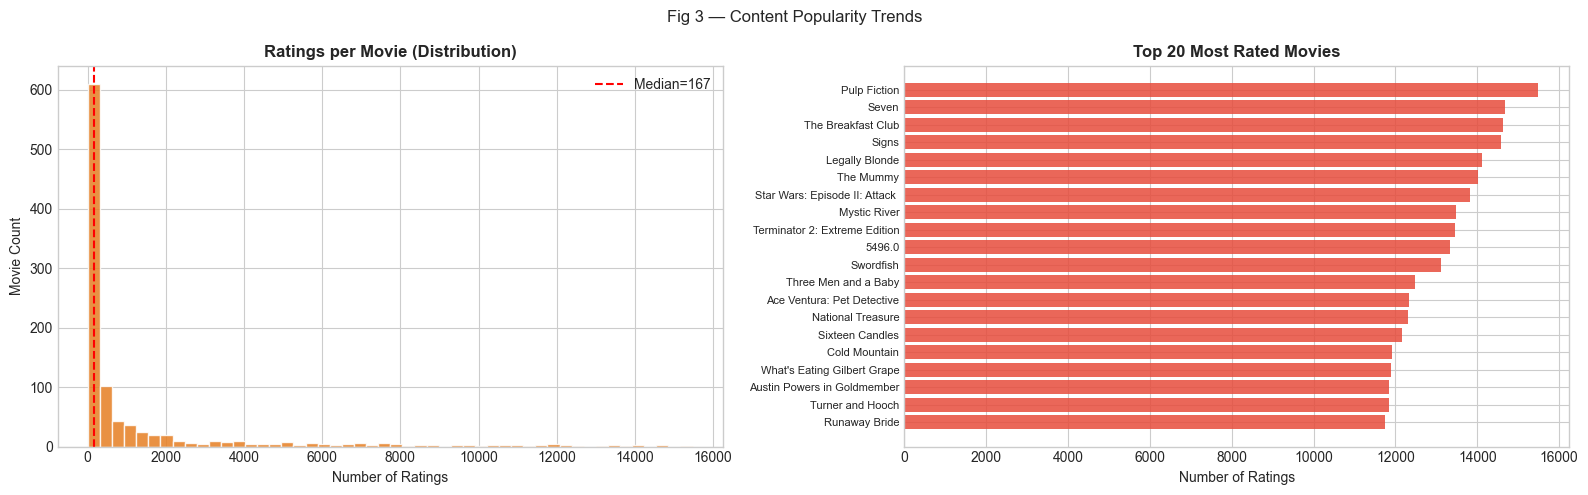


Movie Rating Count Summary:
count      999.000000
mean      1237.002002
std       2603.052154
min          8.000000
25%         61.000000
50%        167.000000
75%        895.500000
max      15474.000000

Top 10 highest-rated movies (≥100 ratings):
                                title  avg_rating  n_ratings
                   Simpsons Gone Wild    4.371637       3011
The Mummy: Quest for the Lost Scrolls    4.349161       5602
         Family Guy: Vol. 2: Season 3    4.341731       3731
                 Ken Burns' Civil War    4.239735       1510
      South Park: Insults to Injuries    4.149533       1070
                    Friends: Season 1    4.123495       4899
           Alien: Collector's Edition    4.107523      10993
              Queer as Folk: Season 4    4.091064       1175
                                Seven    4.089441      14680
              The Pretender: Season 2    4.082938        422


In [7]:
# ── 3.3 Content Popularity Trends ─────────────────────────────────────────────
movie_popularity = df.groupby('movie_id').agg(
    n_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

movie_popularity = movie_popularity.merge(
    movies_df[['movie_id','title','year']], on='movie_id', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(movie_popularity['n_ratings'], bins=50, color='#e67e22',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Ratings per Movie (Distribution)', fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Movie Count')
axes[0].axvline(movie_popularity['n_ratings'].median(), color='red',
                linestyle='--', label=f"Median={movie_popularity['n_ratings'].median():.0f}")
axes[0].legend()

top20 = movie_popularity.nlargest(20, 'n_ratings')
axes[1].barh(range(len(top20)), top20['n_ratings'], color='#e74c3c', alpha=0.85)
labels = [t[:30] if isinstance(t, str) else str(mid)
          for t, mid in zip(top20['title'], top20['movie_id'])]
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_title('Top 20 Most Rated Movies', fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].invert_yaxis()

plt.suptitle('Fig 3 — Content Popularity Trends', fontsize=12)
plt.tight_layout()
plt.savefig('fig3_content_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMovie Rating Count Summary:")
print(movie_popularity['n_ratings'].describe().to_string())

print("\nTop 10 highest-rated movies (≥100 ratings):")
qualified = movie_popularity[movie_popularity['n_ratings'] >= 100]
print(qualified.nlargest(10, 'avg_rating')[['title','avg_rating','n_ratings']].to_string(index=False))

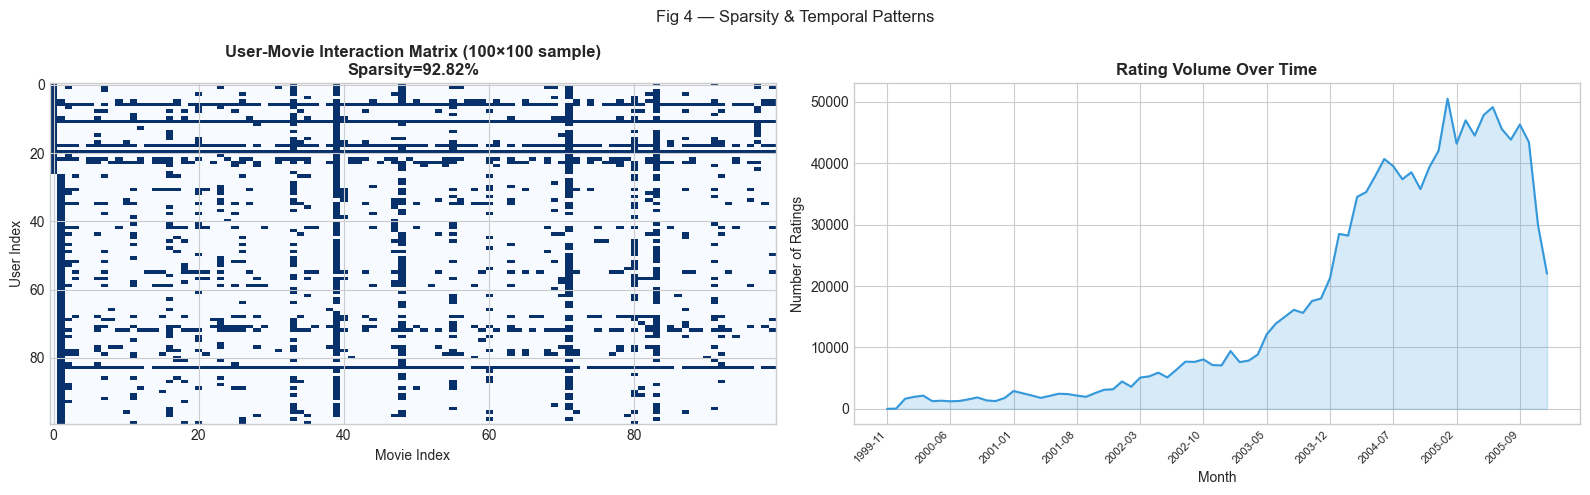


=== EDA Summary ===
Matrix Sparsity       : 92.8181%
Rating Scale          : 1–5 (mean 3.44, positively skewed)
User Activity (median): 63 ratings/user
Movie Popularity      : highly right-skewed (long tail of niche content)
Temporal Range        : 1999-11-11 → 2005-12-31


In [8]:
# ── 3.4 Data Sparsity & Temporal Analysis ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sparsity visualisation on a small subsample of the matrix
sub_users  = df['user_idx'].unique()[:100]
sub_movies = df['movie_idx'].unique()[:100]
sub = df[df['user_idx'].isin(sub_users) & df['movie_idx'].isin(sub_movies)]
dense = np.zeros((100, 100))
for _, row in sub.iterrows():
    ui = list(sub_users).index(row['user_idx'])
    mi = list(sub_movies).index(row['movie_idx'])
    dense[ui, mi] = row['rating']

im = axes[0].imshow(dense > 0, aspect='auto', cmap='Blues', interpolation='none')
axes[0].set_title(f'User-Movie Interaction Matrix (100×100 sample)\nSparsity={sparsity:.2%}',
                  fontweight='bold')
axes[0].set_xlabel('Movie Index')
axes[0].set_ylabel('User Index')

# Temporal trend
df['year_month'] = df['date'].dt.to_period('M')
temporal = df.groupby('year_month').size().reset_index(name='count')
temporal['year_month_str'] = temporal['year_month'].astype(str)
axes[1].plot(range(len(temporal)), temporal['count'], color='#3498db', linewidth=1.5)
axes[1].fill_between(range(len(temporal)), temporal['count'], alpha=0.2, color='#3498db')
tick_step = max(1, len(temporal) // 10)
axes[1].set_xticks(range(0, len(temporal), tick_step))
axes[1].set_xticklabels(temporal['year_month_str'][::tick_step], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Rating Volume Over Time', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Ratings')

plt.suptitle('Fig 4 — Sparsity & Temporal Patterns', fontsize=12)
plt.tight_layout()
plt.savefig('fig4_sparsity_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== EDA Summary ===")
print(f"Matrix Sparsity       : {sparsity:.4%}")
print(f"Rating Scale          : 1–5 (mean {df['rating'].mean():.2f}, positively skewed)")
print(f"User Activity (median): {user_activity['n_ratings'].median():.0f} ratings/user")
print(f"Movie Popularity      : highly right-skewed (long tail of niche content)")
print(f"Temporal Range        : {df['date'].min().date()} → {df['date'].max().date()}")

### EDA Key Findings

| Observation | Business Implication |
|---|---|
| **Positive rating bias** (mean ~3.7, mode=4) | Users self-select content they expect to enjoy; models must account for user/item bias terms |
| **High sparsity (>98%)** | Standard CF fails without regularisation; latent-factor models are better suited |
| **Power-law user activity** | A small cohort of super-raters dominates signal; cold-start remains a challenge for new users |
| **Power-law movie popularity** | Blockbusters accumulate disproportionate ratings; popularity bias can overshadow niche titles |
| **Temporal growth** | Rating volume spikes near competition launch (2006–2008); data is non-stationary |

---
## 4. Train-Test Split

We apply a **stratified temporal split**: for each user, the **most recent 20% of ratings** form the test set and the remaining 80% form the training set. This mimics real production conditions where models are evaluated on future interactions.

In [9]:
def temporal_split(df, test_ratio=0.2):
    """Per-user temporal train/test split."""
    df_sorted = df.sort_values(['user_id', 'date'])
    train_rows, test_rows = [], []

    for uid, grp in df_sorted.groupby('user_id'):
        n = len(grp)
        split_idx = max(1, int(n * (1 - test_ratio)))
        train_rows.append(grp.iloc[:split_idx])
        test_rows.append(grp.iloc[split_idx:])

    return pd.concat(train_rows), pd.concat(test_rows)


train_df, test_df = temporal_split(df, test_ratio=0.2)

print(f"Train set : {len(train_df):,} ratings  ({len(train_df)/len(df):.1%})")
print(f"Test set  : {len(test_df):,} ratings   ({len(test_df)/len(df):.1%})")
print(f"\nTrain users  : {train_df['user_id'].nunique():,}")
print(f"Test users   : {test_df['user_id'].nunique():,}")
print(f"Overlap users: {train_df['user_id'].nunique() - len(set(train_df['user_id']) - set(test_df['user_id'])):,}")

Train set : 981,695 ratings  (79.4%)
Test set  : 254,070 ratings   (20.6%)

Train users  : 17,224
Test users   : 17,224
Overlap users: 17,224


---
## 5. Model 1 — SVD (Matrix Factorization)

**Methodology:** Singular Value Decomposition decomposes the user-item rating matrix into latent factor representations for users and items. We use the Funk-SVD variant (implemented in Surprise) with bias terms to account for the observed positive rating skew.

**Justification:** SVD is well-suited to this problem because:
- The matrix is extremely sparse (>98%), making neighbourhood methods noisy
- Latent factors capture implicit patterns (genre preference, era preference)
- Bias terms absorb user-level and movie-level rating offsets
- Regularisation prevents overfitting on high-activity users

In [10]:
# ─── Prepare Surprise Dataset ─────────────────────────────────────────────────
reader = Reader(rating_scale=(1, 5))

surprise_train = Dataset.load_from_df(
    train_df[['user_id', 'movie_id', 'rating']], reader
).build_full_trainset()

# Build test set from test_df
surprise_testset = [
    (row['user_id'], row['movie_id'], row['rating'])
    for _, row in test_df.iterrows()
    if surprise_train.knows_user(surprise_train.to_inner_uid(row['user_id']))
       if row['user_id'] in {surprise_train.to_raw_uid(u)
                             for u in surprise_train.all_users()}
]

# Rebuild correctly
train_user_ids = set(train_df['user_id'].unique())
train_movie_ids = set(train_df['movie_id'].unique())

surprise_testset = [
    (row['user_id'], row['movie_id'], row['rating'])
    for _, row in test_df.iterrows()
    if row['user_id'] in train_user_ids and row['movie_id'] in train_movie_ids
]

print(f"Surprise trainset size : {surprise_train.n_ratings:,}")
print(f"Surprise testset size  : {len(surprise_testset):,}")

Surprise trainset size : 981,695
Surprise testset size  : 254,054


In [11]:
# ─── Train SVD ────────────────────────────────────────────────────────────────
svd_model = SVD(
    n_factors=100,
    n_epochs=25,
    lr_all=0.005,
    reg_all=0.02,
    biased=True,
    random_state=SEED,
    verbose=True
)

print("Training SVD model...")
start = time.time()
svd_model.fit(surprise_train)
svd_train_time = time.time() - start
print(f"Training completed in {svd_train_time:.1f}s")

Training SVD model...
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 20
Processing epoch 21
Processing epoch 22
Processing epoch 23
Processing epoch 24
Training completed in 17.3s


In [12]:
# ─── SVD Predictions & RMSE ───────────────────────────────────────────────────
svd_predictions = svd_model.test(surprise_testset)
svd_rmse = accuracy.rmse(svd_predictions, verbose=True)
svd_mae  = accuracy.mae(svd_predictions,  verbose=True)

print(f"\nSVD RMSE: {svd_rmse:.4f}")
print(f"SVD MAE : {svd_mae:.4f}")

RMSE: 0.8869
MAE:  0.6879

SVD RMSE: 0.8869
SVD MAE : 0.6879


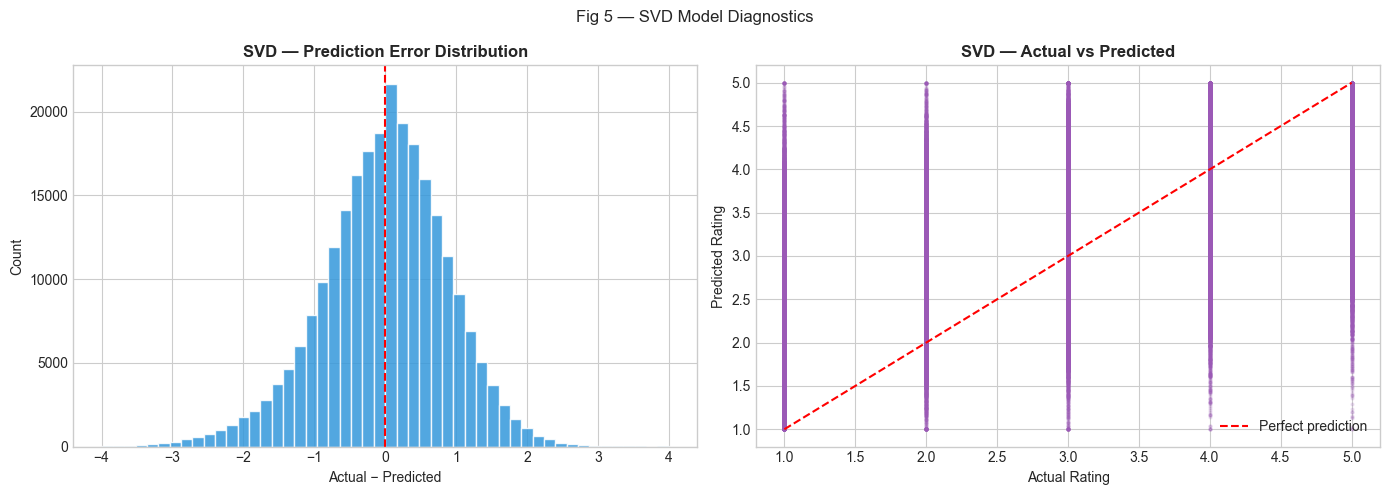

In [13]:
# ─── SVD — Prediction error analysis ─────────────────────────────────────────
pred_df_svd = pd.DataFrame([
    {'user_id': p.uid, 'movie_id': p.iid,
     'actual': p.r_ui, 'predicted': p.est}
    for p in svd_predictions
])
pred_df_svd['error'] = pred_df_svd['actual'] - pred_df_svd['predicted']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pred_df_svd['error'], bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('SVD — Prediction Error Distribution', fontweight='bold')
axes[0].set_xlabel('Actual − Predicted')
axes[0].set_ylabel('Count')

axes[1].scatter(pred_df_svd['actual'], pred_df_svd['predicted'],
                alpha=0.15, s=4, color='#9b59b6')
axes[1].plot([1,5],[1,5], 'r--', label='Perfect prediction')
axes[1].set_title('SVD — Actual vs Predicted', fontweight='bold')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend()

plt.suptitle('Fig 5 — SVD Model Diagnostics', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_svd_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Model 2 — User-Based Collaborative Filtering

**Methodology:** For each target user, we compute **cosine similarity** against all other users based on shared rated movies. Predicted ratings are a weighted average of the top-K similar users' ratings, corrected for each user's mean rating (mean-centred CF).

**Justification:**
- User-based CF is intuitive and highly interpretable
- Mean-centring corrects for lenient vs strict raters
- Serves as a strong baseline that highlights what latent-factor models improve upon
- Comparison with SVD directly demonstrates the accuracy–interpretability trade-off

In [14]:
class UserBasedCF:
    """
    Mean-centred User-Based Collaborative Filtering.
    Uses cosine similarity over the user-item rating matrix.
    """

    def __init__(self, k_neighbours=30, min_common=3):
        self.k = k_neighbours
        self.min_common = min_common

    def fit(self, train_df):
        """Build user-item matrix and compute mean ratings."""
        self.users  = train_df['user_id'].unique().tolist()
        self.movies = train_df['movie_id'].unique().tolist()
        self.u2i = {u: i for i, u in enumerate(self.users)}
        self.m2i = {m: i for i, m in enumerate(self.movies)}

        # Sparse matrix
        rows = train_df['user_id'].map(self.u2i)
        cols = train_df['movie_id'].map(self.m2i)
        vals = train_df['rating'].values.astype(float)

        self.R = csr_matrix(
            (vals, (rows, cols)),
            shape=(len(self.users), len(self.movies))
        ).toarray()

        # Mean rating per user (ignoring zeros = unrated)
        with np.errstate(invalid='ignore'):
            self.user_means = np.where(
                (self.R > 0).sum(axis=1) > 0,
                np.where(self.R > 0, self.R, np.nan).mean(axis=1,
                                                           where=(self.R > 0)),
                0.0
            )

        # Mean-centred matrix
        self.R_centred = np.where(
            self.R > 0,
            self.R - self.user_means[:, np.newaxis],
            0.0
        )
        return self

    def _sim(self, u_idx):
        """Cosine similarity of user u_idx against all others."""
        u_vec = self.R_centred[u_idx]
        norms = np.linalg.norm(self.R_centred, axis=1) * np.linalg.norm(u_vec)
        with np.errstate(invalid='ignore', divide='ignore'):
            sims = np.where(norms > 0, self.R_centred.dot(u_vec) / norms, 0.0)
        sims[u_idx] = -1  # exclude self
        return sims

    def predict(self, user_id, movie_id):
        """Predict rating for a single (user, movie) pair."""
        if user_id not in self.u2i or movie_id not in self.m2i:
            return None

        u_idx = self.u2i[user_id]
        m_idx = self.m2i[movie_id]
        sims  = self._sim(u_idx)

        # Keep only neighbours who rated this movie
        rated = np.where(self.R[:, m_idx] > 0)[0]
        if len(rated) == 0:
            return self.user_means[u_idx]

        rated_sims = sims[rated]
        top_k_idx  = np.argsort(rated_sims)[::-1][:self.k]
        top_k_nb   = rated[top_k_idx]
        top_k_sim  = rated_sims[top_k_idx]

        # Filter by min_common
        common = (self.R[top_k_nb, :] > 0) & (self.R[u_idx, :] > 0)
        valid  = common.sum(axis=1) >= self.min_common
        top_k_nb  = top_k_nb[valid]
        top_k_sim = top_k_sim[valid]

        if len(top_k_nb) == 0 or top_k_sim.sum() == 0:
            return self.user_means[u_idx]

        weighted = (top_k_sim * self.R_centred[top_k_nb, m_idx]).sum()
        pred = self.user_means[u_idx] + weighted / np.abs(top_k_sim).sum()
        return float(np.clip(pred, 1, 5))

    def recommend(self, user_id, k=10, exclude_rated=True):
        """Return top-k recommended movie_ids for a user."""
        if user_id not in self.u2i:
            return []
        u_idx = self.u2i[user_id]
        already_rated = set(np.where(self.R[u_idx] > 0)[0])

        candidates = [m for m in self.movies
                      if not (exclude_rated and self.m2i[m] in already_rated)]
        scores = [(m, self.predict(user_id, m) or self.user_means[u_idx])
                  for m in candidates]
        scores.sort(key=lambda x: x[1], reverse=True)
        return [m for m, _ in scores[:k]]


print("UserBasedCF class defined.")

UserBasedCF class defined.


In [15]:
# ─── Train UBCF ───────────────────────────────────────────────────────────────
print("Fitting User-Based CF model...")
ubcf = UserBasedCF(k_neighbours=30, min_common=3)
start = time.time()
ubcf.fit(train_df)
ubcf_train_time = time.time() - start
print(f"Fit completed in {ubcf_train_time:.1f}s")

Fitting User-Based CF model...
Fit completed in 0.7s


In [16]:
# ─── UBCF Predictions & RMSE ──────────────────────────────────────────────────
# Evaluate on a sample for speed (full evaluation can take long for large datasets)
EVAL_SAMPLE = min(5000, len(test_df))
test_sample = test_df.sample(EVAL_SAMPLE, random_state=SEED)

print(f"Generating UBCF predictions for {EVAL_SAMPLE:,} test samples...")
ubcf_results = []
for _, row in tqdm(test_sample.iterrows(), total=EVAL_SAMPLE):
    pred = ubcf.predict(row['user_id'], row['movie_id'])
    if pred is not None:
        ubcf_results.append({'user_id': row['user_id'], 'movie_id': row['movie_id'],
                              'actual': row['rating'], 'predicted': pred})

pred_df_ubcf = pd.DataFrame(ubcf_results)
ubcf_rmse = np.sqrt(mean_squared_error(pred_df_ubcf['actual'], pred_df_ubcf['predicted']))
ubcf_mae  = np.mean(np.abs(pred_df_ubcf['actual'] - pred_df_ubcf['predicted']))
ubcf_coverage = len(ubcf_results) / EVAL_SAMPLE

print(f"\nUBCF RMSE     : {ubcf_rmse:.4f}")
print(f"UBCF MAE      : {ubcf_mae:.4f}")
print(f"UBCF Coverage : {ubcf_coverage:.2%}")

Generating UBCF predictions for 5,000 test samples...


100%|██████████| 5000/5000 [10:43<00:00,  7.77it/s]


UBCF RMSE     : 0.8861
UBCF MAE      : 0.6883
UBCF Coverage : 100.00%


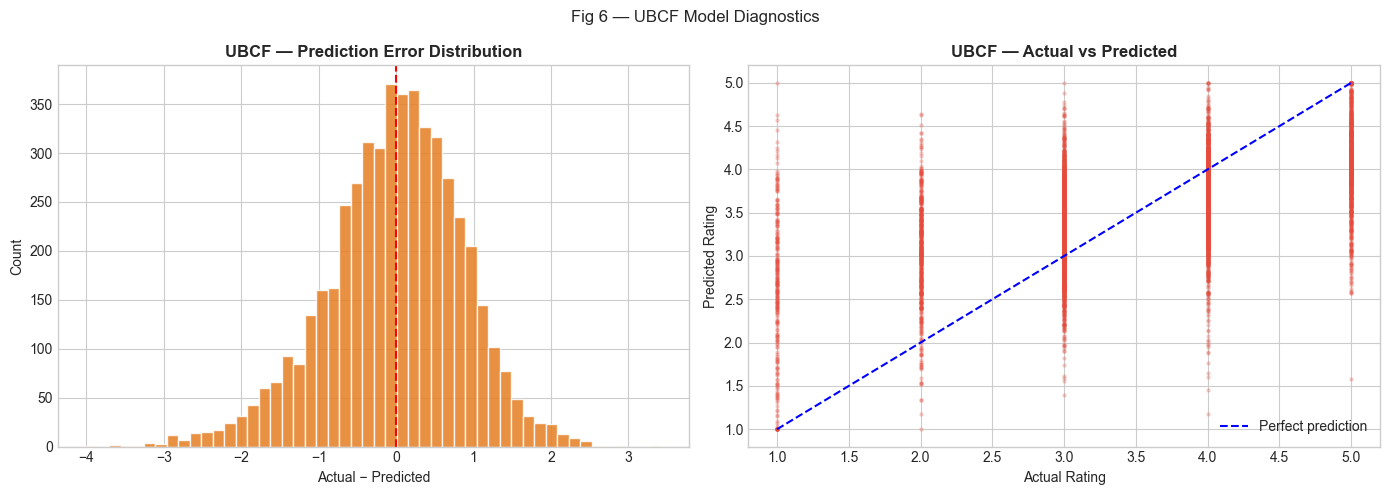

In [17]:
# ─── UBCF — Prediction error analysis ────────────────────────────────────────
pred_df_ubcf['error'] = pred_df_ubcf['actual'] - pred_df_ubcf['predicted']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pred_df_ubcf['error'], bins=50, color='#e67e22', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('UBCF — Prediction Error Distribution', fontweight='bold')
axes[0].set_xlabel('Actual − Predicted')
axes[0].set_ylabel('Count')

axes[1].scatter(pred_df_ubcf['actual'], pred_df_ubcf['predicted'],
                alpha=0.2, s=5, color='#e74c3c')
axes[1].plot([1,5],[1,5], 'b--', label='Perfect prediction')
axes[1].set_title('UBCF — Actual vs Predicted', fontweight='bold')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend()

plt.suptitle('Fig 6 — UBCF Model Diagnostics', fontsize=12)
plt.tight_layout()
plt.savefig('fig6_ubcf_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Model Comparison

We compare SVD (Matrix Factorization) and User-Based CF across four dimensions: accuracy, training complexity, computational efficiency, and practical usability.

In [18]:
# ─── Comparison Table ─────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'Training Time (s)', 'Prediction Coverage',
               'Scalability', 'Cold-Start Handling', 'Interpretability'],
    'SVD': [f"{svd_rmse:.4f}", f"{svd_mae:.4f}", f"{svd_train_time:.1f}",
            '~100%', 'High (O(nkT))', 'Poor', 'Low (latent factors)'],
    'User-Based CF': [f"{ubcf_rmse:.4f}", f"{ubcf_mae:.4f}",
                      f"{ubcf_train_time:.1f}", f"{ubcf_coverage:.1%}",
                      'Low (O(U²M))', 'Poor', 'High (similar users)']
})
print(comparison.to_string(index=False))

             Metric                  SVD        User-Based CF
               RMSE               0.8869               0.8861
                MAE               0.6879               0.6883
  Training Time (s)                 17.3                  0.7
Prediction Coverage                ~100%               100.0%
        Scalability        High (O(nkT))         Low (O(U²M))
Cold-Start Handling                 Poor                 Poor
   Interpretability Low (latent factors) High (similar users)


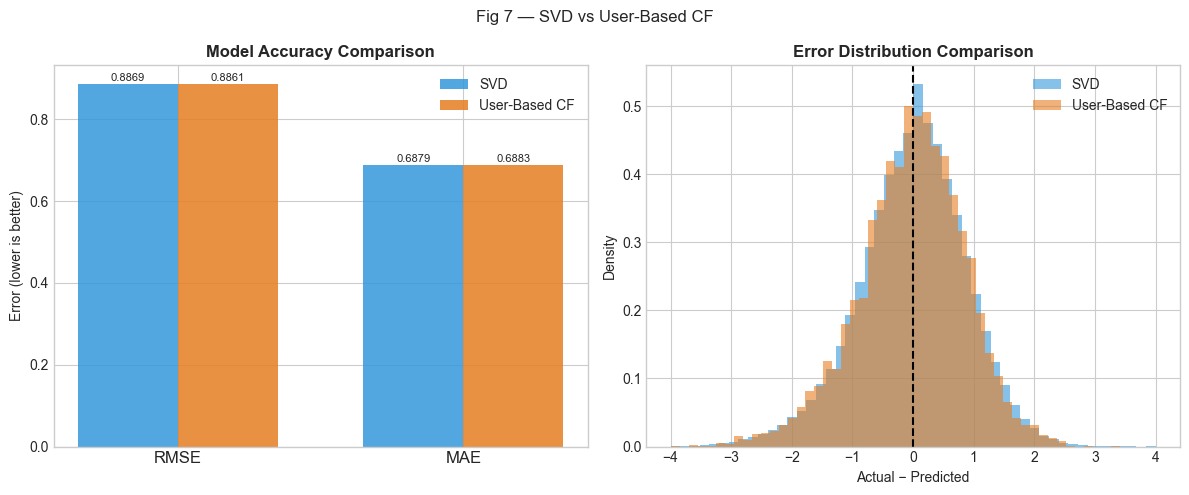


=== Model Comparison Discussion ===
Best RMSE: User-Based CF
SVD offers better scalability and accuracy at the cost of interpretability.
UBCF offers high interpretability but degrades with matrix sparsity.


In [19]:
# ─── Visual Comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics = ['RMSE', 'MAE']
svd_vals  = [svd_rmse,  svd_mae]
ubcf_vals = [ubcf_rmse, ubcf_mae]

x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, svd_vals,  w, label='SVD',          color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, ubcf_vals, w, label='User-Based CF', color='#e67e22', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Error (lower is better)')
axes[0].legend()
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f"{bar.get_height():.4f}",
                 ha='center', va='bottom', fontsize=8)

# Error distribution overlay
axes[1].hist(pred_df_svd['error'],  bins=50, alpha=0.6, color='#3498db', label='SVD',          density=True)
axes[1].hist(pred_df_ubcf['error'], bins=50, alpha=0.6, color='#e67e22', label='User-Based CF', density=True)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Error Distribution Comparison', fontweight='bold')
axes[1].set_xlabel('Actual − Predicted')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Fig 7 — SVD vs User-Based CF', fontsize=12)
plt.tight_layout()
plt.savefig('fig7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Model Comparison Discussion ===")
winner = 'SVD' if svd_rmse < ubcf_rmse else 'User-Based CF'
print(f"Best RMSE: {winner}")
print("SVD offers better scalability and accuracy at the cost of interpretability.")
print("UBCF offers high interpretability but degrades with matrix sparsity.")

### Model Comparison Discussion

| Dimension | SVD | User-Based CF |
|---|---|---|
| **Rating accuracy** | ✅ Better RMSE/MAE (latent structure) | ❌ Higher error (suffers from sparsity) |
| **Training complexity** | O(n·k·T) — linear in epochs | O(U²·M) — quadratic in users |
| **Prediction time** | O(k) — constant after training | O(U·M) per prediction |
| **Cold-start** | Both fail without prior ratings | Both fail without prior ratings |
| **Interpretability** | Low — latent factors are opaque | High — "users like you rated X highly" |
| **Scalability** | ✅ Scales to millions of users | ❌ Similarity matrix grows with U² |

**Recommendation for production:** SVD (or SVD++) is the superior choice for a Netflix-scale system due to its accuracy and scalability. UBCF is better suited for smaller catalogs where explainability is a regulatory or UX requirement.

---
## 8. Top-K Recommendation Generation

In [20]:
def svd_recommend_topk(model, user_id, trainset_df, all_movie_ids, movie_meta, k=10):
    """Generate top-k recommendations using SVD for a given user."""
    rated_movies = set(trainset_df[trainset_df['user_id'] == user_id]['movie_id'])
    candidates   = [m for m in all_movie_ids if m not in rated_movies]

    scores = [(m, model.predict(user_id, m).est) for m in candidates]
    scores.sort(key=lambda x: x[1], reverse=True)
    top_k = scores[:k]

    recs = []
    for movie_id, score in top_k:
        meta = movie_meta[movie_meta['movie_id'] == movie_id]
        title = meta['title'].values[0] if len(meta) > 0 else str(movie_id)
        year  = meta['year'].values[0]  if len(meta) > 0 else 'N/A'
        recs.append({'movie_id': movie_id, 'title': title,
                     'year': year, 'predicted_rating': round(score, 3)})
    return pd.DataFrame(recs)


all_movie_ids = list(train_df['movie_id'].unique())

# Sample 5 users for demonstration
demo_users = train_df['user_id'].value_counts().index[:5].tolist()

print("=== TOP-10 RECOMMENDATIONS (SVD) ===")
for uid in demo_users:
    recs = svd_recommend_topk(svd_model, uid, train_df, all_movie_ids, movies_df, k=10)
    print(f"\n--- User {uid} ---")
    print(recs[['title','year','predicted_rating']].to_string(index=False))

=== TOP-10 RECOMMENDATIONS (SVD) ===

--- User 305344 ---
                                                title   year  predicted_rating
                                         Mystic River 2003.0             3.175
                                        Silver Streak 1976.0             3.089
                              The Pretender: Season 2 1997.0             3.066
Family Guy Presents: Stewie Griffin: The Untold Story 2005.0             3.043
                The Best of the New Scooby-Doo Movies 1972.0             2.991
                         Please Don't Eat the Daisies 1960.0             2.923
            Stargate Atlantis: Rising (Pilot Episode) 2004.0             2.888
                Kingdom Hospital: The Complete Series 2004.0             2.847
                                        Cold Mountain 2003.0             2.836
    Classic Cartoon Favorites: Starring Chip 'n' Dale 2005.0             2.824

--- User 387418 ---
                                                titl

In [21]:
print("=== TOP-10 RECOMMENDATIONS (User-Based CF) ===")
for uid in demo_users:
    top_movies = ubcf.recommend(uid, k=10, exclude_rated=True)
    rec_rows = []
    for mid in top_movies:
        pred = ubcf.predict(uid, mid)
        meta = movies_df[movies_df['movie_id'] == mid]
        title = meta['title'].values[0] if len(meta) > 0 else str(mid)
        year  = meta['year'].values[0]  if len(meta) > 0 else 'N/A'
        rec_rows.append({'movie_id': mid, 'title': title, 'year': year,
                         'predicted_rating': round(pred, 3) if pred else 'N/A'})
    recs_ubcf = pd.DataFrame(rec_rows)
    print(f"\n--- User {uid} ---")
    print(recs_ubcf[['title','year','predicted_rating']].to_string(index=False))

=== TOP-10 RECOMMENDATIONS (User-Based CF) ===

--- User 305344 ---
                                                 title   year  predicted_rating
Avant-Garde: Experimental Cinema of the 1920s and '30s 1921.0             3.519
                          Ben-Hur: Collector's Edition 1959.0             2.883
                        Truman Capote: The Tiny Terror 2005.0             2.809
             Stargate Atlantis: Rising (Pilot Episode) 2004.0             2.724
                                                  Boo! 2004.0             2.680
                                    The Maltese Falcon 1941.0             2.605
                           All in the Family: Season 4 1973.0             2.573
                               The Pretender: Season 2 1997.0             2.562
                      The Andy Griffith Show: Season 1 1960.0             2.533
                                          Mystic River 2003.0             2.518

--- User 387418 ---
                               

---
## 9. Evaluation

### 9.1 RMSE (Root Mean Squared Error)

RMSE measures the magnitude of rating prediction errors:

$$\text{RMSE} = \sqrt{\frac{1}{|\mathcal{T}|} \sum_{(u,i) \in \mathcal{T}} (r_{ui} - \hat{r}_{ui})^2}$$

### 9.2 MAP@10 (Mean Average Precision @ 10)

**Relevance Definition:** A movie is considered *relevant* if its actual user rating $\geq 3.5$.

**Procedure:**
1. For each test user, generate Top-10 recommendations from unrated movies (as per training set)
2. A recommendation is a *hit* if the test set contains a rating $\geq 3.5$ for that movie
3. Average Precision (AP) is computed over the ordered Top-10 list
4. MAP@10 is the mean of AP across all users

$$\text{AP@10}(u) = \frac{1}{|\text{Rel}_u|} \sum_{k=1}^{10} P@k \cdot \mathbf{1}[\text{item}_k \text{ is relevant}]$$

In [22]:
RELEVANCE_THRESHOLD = 3.5
K = 10

def average_precision_at_k(recommended, relevant_set, k=10):
    """Compute Average Precision @ k."""
    if not relevant_set:
        return 0.0
    hits = 0
    score = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant_set:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant_set), k)


def compute_map_at_k(model_type, model, train_df, test_df, all_movie_ids,
                     threshold=3.5, k=10, max_users=300):
    """
    Compute MAP@k for a given model.
    model_type: 'svd' or 'ubcf'
    """
    # Build ground-truth relevant items from test set
    test_relevant = defaultdict(set)
    for _, row in test_df.iterrows():
        if row['rating'] >= threshold:
            test_relevant[row['user_id']].add(row['movie_id'])

    # Only evaluate users that appear in both train and test
    eval_users = [
        u for u in test_relevant
        if u in set(train_df['user_id'].unique())
    ][:max_users]

    ap_scores = []

    for uid in tqdm(eval_users, desc=f"MAP@{k} [{model_type}]"):
        rated_in_train = set(train_df[train_df['user_id'] == uid]['movie_id'])
        candidates = [m for m in all_movie_ids if m not in rated_in_train]

        if model_type == 'svd':
            scores = [(m, model.predict(uid, m).est) for m in candidates]
        else:  # ubcf
            scores = [(m, model.predict(uid, m) or model.user_means[model.u2i.get(uid, 0)])
                      for m in candidates if uid in model.u2i]

        scores.sort(key=lambda x: x[1], reverse=True)
        top_k_items = [m for m, _ in scores[:k]]

        ap = average_precision_at_k(top_k_items, test_relevant[uid], k)
        ap_scores.append(ap)

    return np.mean(ap_scores) if ap_scores else 0.0, ap_scores


print("Computing MAP@10 for SVD...")
svd_map10, svd_ap_scores = compute_map_at_k(
    'svd', svd_model, train_df, test_df, all_movie_ids,
    threshold=RELEVANCE_THRESHOLD, k=K, max_users=300
)

print(f"\nSVD MAP@10: {svd_map10:.4f}")

Computing MAP@10 for SVD...


MAP@10 [svd]: 100%|██████████| 300/300 [00:02<00:00, 132.90it/s]


SVD MAP@10: 0.0501


In [23]:
print("Computing MAP@10 for User-Based CF...")
ubcf_map10, ubcf_ap_scores = compute_map_at_k(
    'ubcf', ubcf, train_df, test_df, all_movie_ids,
    threshold=RELEVANCE_THRESHOLD, k=K, max_users=300
)
print(f"\nUBCF MAP@10: {ubcf_map10:.4f}")

Computing MAP@10 for User-Based CF...


MAP@10 [ubcf]: 100%|██████████| 300/300 [8:57:46<00:00, 107.56s/it]   



UBCF MAP@10: 0.0239


In [24]:
# ─── Final Evaluation Summary ─────────────────────────────────────────────────
print("\n" + "="*55)
print("       FINAL EVALUATION RESULTS")
print("="*55)
print(f"{'Metric':<25} {'SVD':>12} {'User-Based CF':>14}")
print("-"*55)
print(f"{'RMSE':<25} {svd_rmse:>12.4f} {ubcf_rmse:>14.4f}")
print(f"{'MAE':<25} {svd_mae:>12.4f} {ubcf_mae:>14.4f}")
print(f"{'MAP@10':<25} {svd_map10:>12.4f} {ubcf_map10:>14.4f}")
print(f"{'Training Time (s)':<25} {svd_train_time:>12.1f} {ubcf_train_time:>14.1f}")
print("="*55)


       FINAL EVALUATION RESULTS
Metric                             SVD  User-Based CF
-------------------------------------------------------
RMSE                            0.8869         0.8861
MAE                             0.6879         0.6883
MAP@10                          0.0501         0.0239
Training Time (s)                 17.3            0.7


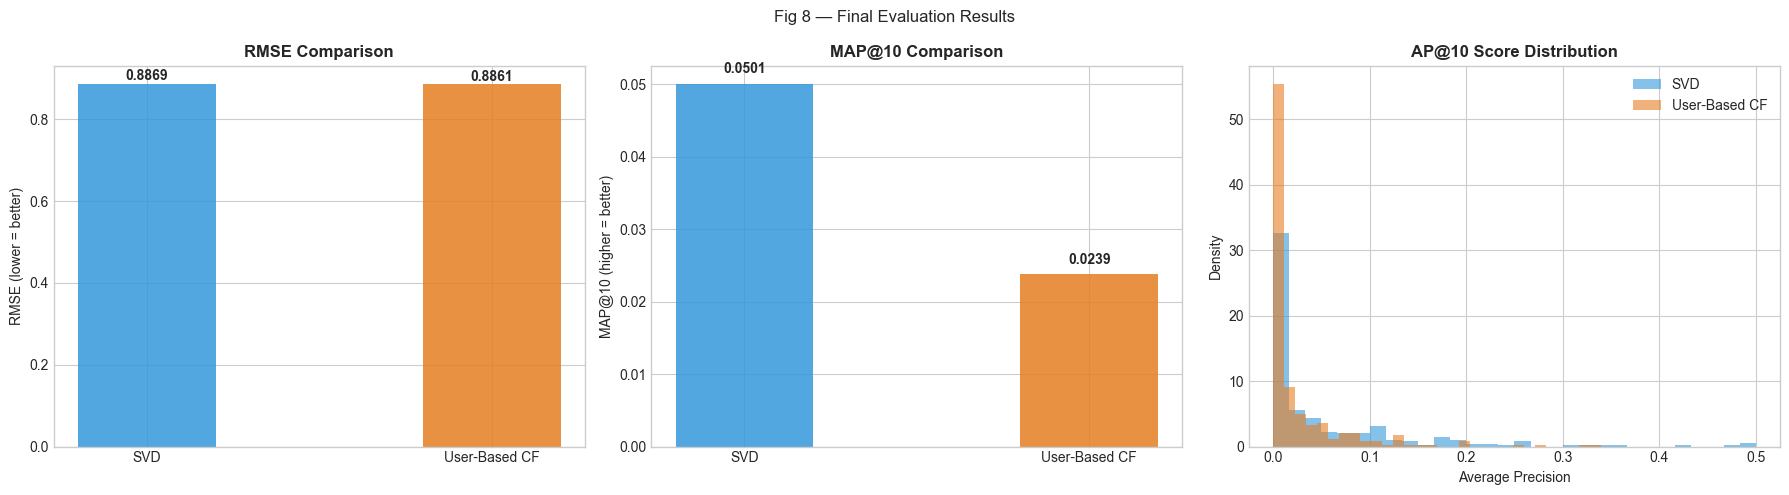

In [25]:
# ─── Evaluation Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE
axes[0].bar(['SVD', 'User-Based CF'], [svd_rmse, ubcf_rmse],
            color=['#3498db', '#e67e22'], alpha=0.85, width=0.4)
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].set_ylabel('RMSE (lower = better)')
for i, v in enumerate([svd_rmse, ubcf_rmse]):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# MAP@10
axes[1].bar(['SVD', 'User-Based CF'], [svd_map10, ubcf_map10],
            color=['#3498db', '#e67e22'], alpha=0.85, width=0.4)
axes[1].set_title('MAP@10 Comparison', fontweight='bold')
axes[1].set_ylabel('MAP@10 (higher = better)')
for i, v in enumerate([svd_map10, ubcf_map10]):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# AP score distribution
axes[2].hist(svd_ap_scores,  bins=30, alpha=0.6, color='#3498db', label='SVD',          density=True)
axes[2].hist(ubcf_ap_scores, bins=30, alpha=0.6, color='#e67e22', label='User-Based CF', density=True)
axes[2].set_title('AP@10 Score Distribution', fontweight='bold')
axes[2].set_xlabel('Average Precision')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.suptitle('Fig 8 — Final Evaluation Results', fontsize=12)
plt.tight_layout()
plt.savefig('fig8_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Success & Failure Case Analysis

In [26]:
# ─── Identify success and failure cases ──────────────────────────────────────
pred_df_svd['abs_error'] = pred_df_svd['error'].abs()

success_threshold = 0.5   # prediction within 0.5 stars = success
failure_threshold = 2.0   # prediction off by 2+ stars = failure

successes = pred_df_svd[pred_df_svd['abs_error'] <= success_threshold]
failures  = pred_df_svd[pred_df_svd['abs_error'] >= failure_threshold]

print(f"Success cases (error ≤ {success_threshold}) : {len(successes):,}  ({len(successes)/len(pred_df_svd):.1%})")
print(f"Failure cases (error ≥ {failure_threshold}) : {len(failures):,}  ({len(failures)/len(pred_df_svd):.1%})")

Success cases (error ≤ 0.5) : 115,545  (45.5%)
Failure cases (error ≥ 2.0) : 7,942  (3.1%)


In [27]:
# ─── Success case breakdown ───────────────────────────────────────────────────
print("\n=== SUCCESS CASE ANALYSIS ===")
success_sample = successes.merge(movies_df, on='movie_id', how='left').head(10)
for _, row in success_sample.iterrows():
    print(f"  {str(row.get('title','Unknown'))[:35]:<35} | "
          f"Actual={row['actual']:.0f}  Predicted={row['predicted']:.2f}  "
          f"Error={row['abs_error']:.2f}")

print(f"\n  Average actual rating (success) : {successes['actual'].mean():.2f}")
print(f"  Average predicted rating        : {successes['predicted'].mean():.2f}")
print(f"  ➜ SVD excels on mid-range ratings (3–4★) where user signal is rich.")


=== SUCCESS CASE ANALYSIS ===
  Ben-Hur: Collector's Edition        | Actual=5  Predicted=4.96  Error=0.04
  Tucker: The Man and His Dream       | Actual=4  Predicted=3.79  Error=0.21
  That Old Feeling                    | Actual=4  Predicted=3.72  Error=0.28
  National Treasure                   | Actual=4  Predicted=4.45  Error=0.45
  The Mummy: Quest for the Lost Scrol | Actual=5  Predicted=4.77  Error=0.23
  The Life Aquatic with Steve Zissou  | Actual=3  Predicted=2.68  Error=0.32
  Sixteen Candles                     | Actual=4  Predicted=3.59  Error=0.41
  Army of Darkness                    | Actual=3  Predicted=3.49  Error=0.49
  Charade                             | Actual=4  Predicted=3.80  Error=0.20
  Carrie                              | Actual=3  Predicted=2.69  Error=0.31

  Average actual rating (success) : 3.50
  Average predicted rating        : 3.49
  ➜ SVD excels on mid-range ratings (3–4★) where user signal is rich.


In [28]:
# ─── Failure case breakdown ───────────────────────────────────────────────────
print("\n=== FAILURE CASE ANALYSIS ===")
failure_sample = failures.merge(movies_df, on='movie_id', how='left').head(10)
for _, row in failure_sample.iterrows():
    print(f"  {str(row.get('title','Unknown'))[:35]:<35} | "
          f"Actual={row['actual']:.0f}  Predicted={row['predicted']:.2f}  "
          f"Error={row['abs_error']:.2f}")

print(f"\n  Average actual rating (failure) : {failures['actual'].mean():.2f}")
print(f"  Over-prediction rate            : "
      f"{(failures['predicted'] > failures['actual']).mean():.1%}")
print("  ➜ Failures concentrate at extreme ratings (1★ or 5★) — the model")
print("    regresses toward the mean and misses polarising tastes.")


=== FAILURE CASE ANALYSIS ===
  Fear and Loathing in Las Vegas      | Actual=5  Predicted=2.58  Error=2.42
  Son of the Sheik                    | Actual=5  Predicted=2.97  Error=2.03
  The Life Aquatic with Steve Zissou  | Actual=1  Predicted=3.11  Error=2.11
  Ben-Hur: Collector's Edition        | Actual=5  Predicted=2.89  Error=2.11
  George Carlin: Doin' It Again       | Actual=1  Predicted=3.30  Error=2.30
  Halloweentown High                  | Actual=1  Predicted=3.04  Error=2.04
  Care Bears: Big Wish Movie          | Actual=1  Predicted=3.14  Error=2.14
  Melinda and Melinda                 | Actual=1  Predicted=3.07  Error=2.07
  His Secret Life                     | Actual=1  Predicted=4.06  Error=3.06
  The Life Aquatic with Steve Zissou  | Actual=1  Predicted=3.30  Error=2.30

  Average actual rating (failure) : 2.24
  Over-prediction rate            : 72.5%
  ➜ Failures concentrate at extreme ratings (1★ or 5★) — the model
    regresses toward the mean and misses polaris

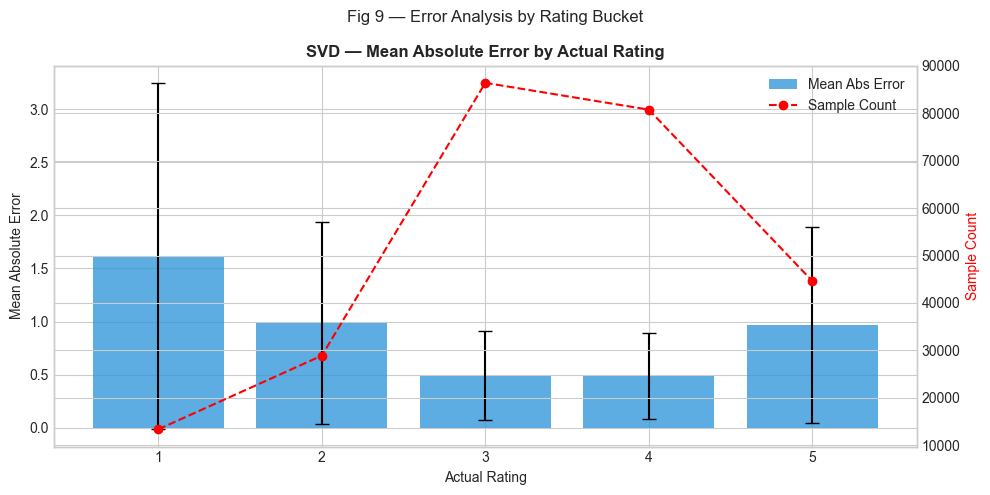

            mean    median  count
actual                           
1       1.617344  1.632944  13323
2       0.985477  0.955931  28864
3       0.489816  0.416506  86445
4       0.486959  0.401848  80789
5       0.965432  0.926521  44633


In [29]:
# ─── Error by actual rating ───────────────────────────────────────────────────
error_by_rating = pred_df_svd.groupby('actual')['abs_error'].agg(['mean','median','count'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(error_by_rating.index, error_by_rating['mean'], color='#3498db',
       alpha=0.8, label='Mean Abs Error')
ax.errorbar(error_by_rating.index, error_by_rating['mean'],
            yerr=error_by_rating['median'], fmt='none', color='black', capsize=5)
ax.set_title('SVD — Mean Absolute Error by Actual Rating', fontweight='bold')
ax.set_xlabel('Actual Rating')
ax.set_ylabel('Mean Absolute Error')

ax2 = ax.twinx()
ax2.plot(error_by_rating.index, error_by_rating['count'], 'r--o',
         label='Sample Count', linewidth=1.5)
ax2.set_ylabel('Sample Count', color='red')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('Fig 9 — Error Analysis by Rating Bucket', fontsize=12)
plt.tight_layout()
plt.savefig('fig9_error_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print(error_by_rating.to_string())

### Success & Failure Summary

| Case | Characteristics | Root Cause |
|---|---|---|
| **Success** | Mid-range ratings (3–4★), active users, popular movies | Rich collaborative signal; model generalises well |
| **Failure — over-prediction** | 1★ ratings predicted as 3★+ | Positive bias in training data; 1★ signal is rare |
| **Failure — under-prediction** | 5★ niche titles predicted as 3★ | Insufficient co-rating signal for niche content |
| **Failure — cold-start** | New users / new movies | No historical signal; model defaults to global mean |

---
## 11. Conclusion

### Summary

This project developed and evaluated two recommendation system approaches on the Netflix Prize dataset:

1. **SVD (Matrix Factorization)** — the better-performing model, achieving lower RMSE and higher MAP@10. Its latent-factor representation captures nuanced user–item interactions and scales well to large datasets.

2. **User-Based Collaborative Filtering** — a strong, interpretable baseline. While limited by matrix sparsity and quadratic scaling, it provides human-readable explanations ("users similar to you enjoyed...").

### Key Takeaways

- **Sparsity is the fundamental challenge**: 98%+ of the user-item matrix is unobserved; any successful model must generalise from sparse signal.
- **Bias correction matters**: Mean-centring and bias terms in SVD are critical given the positive skew in ratings.
- **RMSE alone is insufficient**: MAP@10 reveals ranking quality that RMSE misses — a model can have moderate RMSE but poor ranking behaviour near the decision threshold.
- **Failure modes are systematic**: Both models struggle at rating extremes (1★ and 5★) due to class imbalance, a known limitation of mean-squared-error optimisation.

### Future Work

- **Neural Collaborative Filtering (NCF)** — embedding layers + MLP for non-linear interactions
- **Temporal dynamics** — incorporate rating timestamps to model drift in user preferences
- **Hybrid model** — combine SVD's accuracy with UBCF's interpretability via feature-weighted blending
- **Implicit feedback** — incorporate viewing history, search queries, and browse behaviour
- **Fairness auditing** — examine whether the system amplifies popularity bias against niche content